In [1]:
from hazm import *
import string
import re
import pandas as pd
import fasttext
from Preprocessor import Preprocessor
import numpy as np
from PCA import PCA
from Cluster_Metrics import adjusted_rand_score
from sklearn.metrics import *
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import seaborn as sns
from Model import *
from scipy import stats
from LogisticRegression import *
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
from FishersLDA import FishersLDA
from CosineKernel import CosineKernel
from KernelDensityClassifier import KernelDensityClassifier

In [2]:
def load_dataset():
    dataset = pd.DataFrame()
    for i in range(2, 66):
        if i != 3:
            file_path = '..\\dataset\\split_' + str(i) + '.xlsx'
            with pd.ExcelFile(file_path) as xls:
                data = pd.read_excel(xls)
            data = data[['comment', 'label']]
            dataset = pd.concat([dataset, data])
    return dataset

In [3]:
dataset = load_dataset()

In [4]:
preprocessor = Preprocessor()
dataset = preprocessor.preprocessing(dataset)

In [5]:
with open('dataset.txt', 'w', encoding='utf-8') as file:
    for index, row in dataset.iterrows():
        line = f"{row['comment']}\n"
        file.write(line)

# cells Bellow are not part of Code, they were experiments.

In [40]:
unique_words = set()
for tokens in dataset['tokens'].values:
    for token in tokens:
        unique_words.add(token)
word_to_index = {word: i for i, word in enumerate(unique_words)}

In [7]:
len(unique_words)

28088

In [ ]:
def tokens_to_array(tokens, word_to_index, length):
    array = np.zeros(length, dtype=int)
    indices = [word_to_index[token] for token in tokens if token in word_to_index]
    array[indices] = 1
    return array

In [ ]:
dataset['binary_arrays'] = dataset['tokens'].apply(lambda tokens: tokens_to_array(tokens, word_to_index, len(unique_words)))

In [ ]:
max_length = dataset['tokens'].apply(len).max()
print("Maximum length of arrays in 'tokens' column:", max_length)

In [59]:
from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(chi2, k=50)
X_new = selector.fit_transform(X, y)
selected_features_mask = selector.get_support()
selected_feature_indexes = [i for i, x in enumerate(selected_features_mask) if x]

In [60]:
zero_rows_indices = np.where(np.all(X_new == 0, axis=1))[0]

In [8]:
def aggregate_vectors_tfidf(comments, model, tfidf_vectorizer):
    tfidf_matrix = tfidf_vectorizer.transform(comments)
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    aggregated_vectors = []
    word_vectors = np.array([model.get_word_vector(word) if word in model else np.zeros(model.get_dimension()) for word in feature_names])
    
    for row in range(tfidf_matrix.shape[0]):
        tfidf_scores = tfidf_matrix[row].toarray().flatten()
        sum_tfidf_scores = np.sum(tfidf_scores)
        if sum_tfidf_scores == 0:
            aggregated_vectors.append(np.zeros(model.get_dimension()))
        else:
            weighted_average = np.dot(tfidf_scores, word_vectors)
            aggregated_vectors.append(weighted_average / sum_tfidf_scores)

    return aggregated_vectors


# Finding Stop words

In [8]:
tfidf_vectorizera = TfidfVectorizer()
tfidf_vectorizera.fit(dataset['comment'].values)

TfidfVectorizer()

In [14]:
def find_stop_words(tfidf_vectorizer):
    idf_scores = tfidf_vectorizer.idf_
    feature_names = tfidf_vectorizer.get_feature_names_out()
    max_idf_threshold = 11
    min_idf_threshold = 2
    stop_words = [word for word, score in zip(feature_names, idf_scores) if not (min_idf_threshold <=score <= max_idf_threshold)]
    print(len(stop_words))
    with open("stop_words.txt", 'w', encoding='utf-8') as file:
        for word in stop_words:
            file.write(word + '\n')
    print("Stop words saved to: stop_words.txt")

In [15]:
# find_stop_words(tfidf_vectorizera)

22560
Stop words saved to: stop_words.txt


# Fasttext Embedding

In [6]:
embedded_model = fasttext.train_unsupervised(input="dataset.txt", model='skipgram', minn=2, maxn=3, dim=250)

In [7]:
# experiment test (1 way to calcaulate features)

# aggregated_vectors = aggregate_vectors_tfidf(dataset['comment'].values, embedded_model, tfidf_vectorizera)
# scaler = StandardScaler()
# aggregated_vectors = scaler.fit_transform(np.array(aggregated_vectors))
# dataset['embedded'] = list(aggregated_vectors)

In [8]:
def aggregate_vectors(comment, model):
    vectors = [model.get_word_vector(word) for word in comment]
    if not vectors:
        return None
    aggregated_vector = np.mean(vectors, axis=0)
    return aggregated_vector

In [9]:
data_matrix = []
for i in dataset['tokens']:
    vector = aggregate_vectors(i, embedded_model)
    data_matrix.append(vector)
scaler = StandardScaler()
data_matrix = scaler.fit_transform(np.array(data_matrix))
dataset['embedded'] = list(data_matrix)

# Outlier detection

In [10]:
def detect_outliers_z_score(dataset, threshold):
    z_scores = dataset['embedded'].apply(lambda x: np.abs(stats.zscore(x, nan_policy='omit')))
    is_outlier = [any(value > threshold for value in row) for row in z_scores]
    dataset['is_outlier'] = is_outlier
    outlier_counts = pd.DataFrame(index=np.unique(dataset['label']), columns=['Outlier Count'])
    for class_label in outlier_counts.index:
        class_outliers = dataset.loc[(dataset['label'] == class_label) & dataset['is_outlier']]
        outlier_counts.loc[class_label, 'Outlier Count'] = len(class_outliers)
    print("Outlier Counts for Each Class threshold is :",threshold)
    print(outlier_counts)
    dataset.drop(columns='is_outlier', inplace=True)
    return is_outlier

In [11]:
def detect_outlier_IQR(dataset, alpha):
    dataaa = []
    for row in dataset['embedded']:
        dataaa.append(list(row))
    data_array = np.array(dataaa)
    Q1 = np.percentile(data_array, 25, axis=0)
    Q3 = np.percentile(data_array, 75, axis=0)
    IQR = Q3 - Q1
    lower_bound = Q1 - alpha * IQR
    upper_bound = Q3 + alpha * IQR
    outliers_indices = np.where((data_array < lower_bound) | (data_array > upper_bound))[0]
    is_outlier = [False] * len(data_array)
    for idx in outliers_indices:
        is_outlier[idx] = True

    dataset['is_outlier'] = is_outlier
    outlier_counts = pd.DataFrame(index=np.unique(dataset['label']), columns=['Outlier Count'])
    for class_label in outlier_counts.index:
        class_outliers = dataset.loc[(dataset['label'] == class_label) & dataset['is_outlier']]
        outlier_counts.loc[class_label, 'Outlier Count'] = len(class_outliers)
    print("Outlier Counts for Each Class alpha is :", alpha)
    print(outlier_counts)
    dataset.drop(columns='is_outlier', inplace=True)
    return is_outlier

In [12]:
def outlier_removal(data,outlier):
    data_no_outlier = data
    data_no_outlier['is_outlier'] = outlier
    data_no_outlier = data_no_outlier[~data_no_outlier['is_outlier'].eq(True)]
    data_no_outlier.reset_index(drop=True, inplace=True)
    data_no_outlier_copy = data_no_outlier.copy()
    data_no_outlier_copy.drop(columns='is_outlier',inplace=True)
    return data_no_outlier_copy

In [16]:
outliers = detect_outliers_z_score(dataset, 3)

Outlier Counts for Each Class threshold is : 3
   Outlier Count
-1          6567
 0          2300
 1         15550


In [62]:
outliers = detect_outlier_IQR(dataset, 4)

Outlier Counts for Each Class alpha is : 4
   Outlier Count
-1           945
 0           210
 1          2120


In [63]:
X = list(dataset['embedded'])
y = dataset['label'].values

In [64]:
dataset_without_out = outlier_removal(dataset, outliers)
X = list(dataset_without_out['embedded'])
y = dataset_without_out['label'].values

# Imbalance data

In [65]:
y_one_hot = label_binarize(y, classes=np.unique(y))
class_counts_train = np.sum(y_one_hot, axis=0)
print("Before sampling: ", class_counts_train)

under_resampling_strategy = {
    0: 13593,
    1: 4469,
    2: 30000
}

over_resampling_strategy = {
    0: 30000,
    1: 30000,
    2: 30000
}

pipeline = Pipeline([
#     ('under', RandomUnderSampler(sampling_strategy=under_resampling_strategy, random_state=42)),
#     ('over', RandomOverSampler(sampling_strategy=over_resampling_strategy, random_state=42)),
    ('smote', SMOTE(random_state=42))
])

X_resampled, y_resampled = pipeline.fit_resample(X, y_one_hot)
class_counts_train_resampled = np.sum(y_resampled, axis=0)
print("After sampling: ", class_counts_train_resampled)

Before sampling:  [16100  5391 38019]
After sampling:  [38019 38019 38019]


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.01, random_state=42)

In [67]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Softmax

In [58]:
softmax_clf = SoftmaxClassifier(learning_rate=0.4, num_iterations=10000, regularization_strength=0.05)
softmax_clf.fit(X_train, np.argmax(y_train, axis=1))

In [61]:
y_pred_test = softmax_clf.predict(X_test)
accuracy = accuracy_score(np.argmax(y_test, axis=1), y_pred_test)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.7449078564500485


In [62]:
y_pred_train = softmax_clf.predict(X_train)
accuracy = accuracy_score(np.argmax(y_train, axis=1), y_pred_train)
print(f"Train Accuracy: {accuracy}")

Train Accuracy: 0.7407530855725587


In [63]:
y_pred_prob = softmax_clf.predict_prob(X_test)
auc_roc_per_class = [roc_auc_score(y_test[:, i], y_pred_prob[:, i]) for i in range(len(np.unique(np.argmax(y_test, axis=1))))]
print("AUC-ROC per class:")
for i, auc in enumerate(auc_roc_per_class):
    print(f"Class {i}: {auc:.2f}")

AUC-ROC per class:
Class 0: 0.92
Class 1: 0.85
Class 2: 0.91


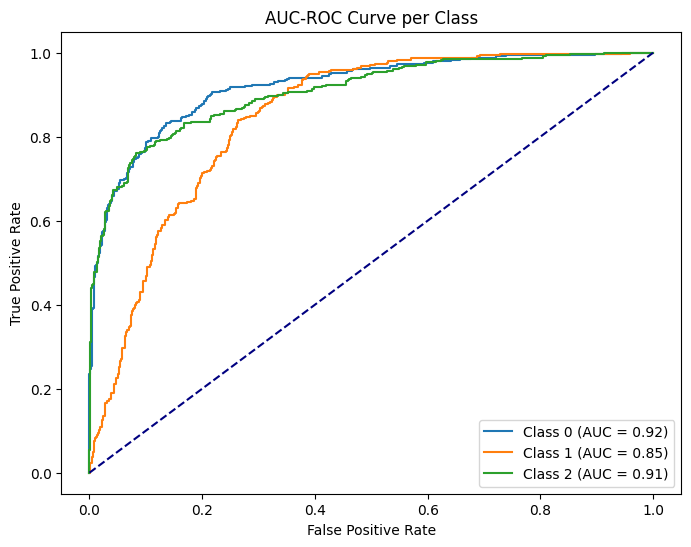

In [64]:
plt.figure(figsize=(8, 6))
for i in range(len(np.unique(np.argmax(y_test, axis=1)))):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve per Class')
plt.legend(loc='lower right')
plt.show()


In [65]:
report = classification_report(np.argmax(y_test, axis=1), y_pred_test)
print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       339
           1       0.63      0.74      0.68       341
           2       0.84      0.73      0.78       351

    accuracy                           0.74      1031
   macro avg       0.76      0.75      0.75      1031
weighted avg       0.76      0.74      0.75      1031



In [66]:
report = classification_report(np.argmax(y_train, axis=1), y_pred_train)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.77     34007
           1       0.64      0.73      0.68     34005
           2       0.82      0.74      0.78     33995

    accuracy                           0.74    102007
   macro avg       0.75      0.74      0.74    102007
weighted avg       0.75      0.74      0.74    102007



In [67]:
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_test)
print(cm)

[[260  70   9]
 [ 47 253  41]
 [ 18  78 255]]


In [72]:
cm = confusion_matrix(np.argmax(y_train, axis=1), y_pred_train)
print(cm)

[[25616  7009  1382]
 [ 4968 24742  4295]
 [ 2130  6661 25204]]


# OVA

In [73]:
ova_model = OvA(LogisticRegression)
ova_model.train(X_train, np.argmax(y_train, axis=1))

In [74]:
y_pred_test_ova = ova_model.predict(X_test)
accuracy = accuracy_score(np.argmax(y_test, axis=1), y_pred_test_ova)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.6838021338506305


In [75]:
y_pred_train_ova = ova_model.predict(X_train)
accuracy = accuracy_score(np.argmax(y_train, axis=1), y_pred_train_ova)
print(f"Train Accuracy: {accuracy}")

Train Accuracy: 0.677786818551668


In [77]:
report = classification_report(np.argmax(y_test, axis=1), y_pred_test_ova)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.85      0.72       339
           1       0.64      0.55      0.59       341
           2       0.83      0.65      0.73       351

    accuracy                           0.68      1031
   macro avg       0.70      0.68      0.68      1031
weighted avg       0.70      0.68      0.68      1031



In [78]:
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_test_ova)
print(cm)

[[289  40  10]
 [117 188  36]
 [ 58  65 228]]


In [79]:
cm = confusion_matrix(np.argmax(y_train, axis=1), y_pred_train_ova)
print(cm)

[[28376  4564  1067]
 [11868 18535  3602]
 [ 5536  6231 22228]]


# OVO

In [80]:
ovo_model = OvO(LogisticRegression)
ovo_model.train(X_train, np.argmax(y_train, axis=1))

In [82]:
y_pred_test_ovo = ovo_model.predict(X_test)
accuracy = accuracy_score(np.argmax(y_test, axis=1), y_pred_test_ovo)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.7206595538312318


In [83]:
y_pred_train_ovo = ovo_model.predict(X_train)
accuracy = accuracy_score(np.argmax(y_train, axis=1), y_pred_train_ovo)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.7161763408393541


In [84]:
report = classification_report(np.argmax(y_test, axis=1), y_pred_test_ovo)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       339
           1       0.62      0.67      0.65       341
           2       0.80      0.72      0.76       351

    accuracy                           0.72      1031
   macro avg       0.72      0.72      0.72      1031
weighted avg       0.73      0.72      0.72      1031



In [31]:
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_ovo)
print(cm)

[[265  65  26]
 [ 65 222  52]
 [ 33  70 242]]


# Dimensionality reduction

In [68]:
lda = FishersLDA()
lda.fit(X_train, np.argmax(y_train , axis=1))
transformed_train = np.real(lda.transform(X_train))
transformed_test = np.real(lda.transform(X_test))

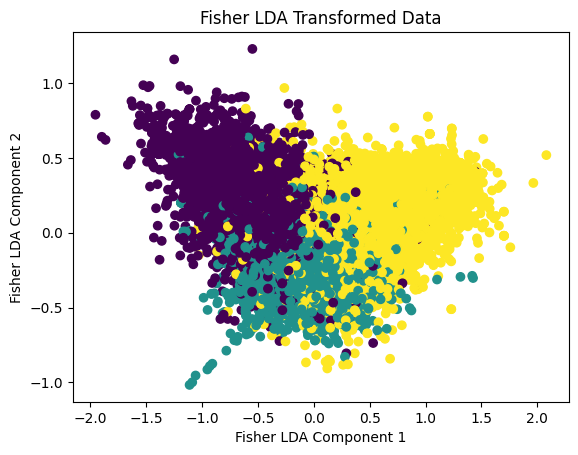

In [69]:
plt.scatter(transformed_train[:, 0], transformed_train[:, 1], c=np.argmax(y_train,axis=1), cmap='viridis')
plt.xlabel('Fisher LDA Component 1')
plt.ylabel('Fisher LDA Component 2')
plt.title('Fisher LDA Transformed Data')
plt.show()

# KDE CLASSIFICATION

In [70]:
kde = KernelDensityClassifier(0.2)

In [71]:
kde.fit(transformed_train,y_train)

In [72]:
y_test_pred = kde.predict(transformed_test)

In [73]:
accuracy = accuracy_score(np.argmax(y_test,axis=1), y_test_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.7563540753724802


In [74]:
y_train_pred = kde.predict(transformed_train)

In [75]:
accuracy = accuracy_score(np.argmax(y_train,axis=1), y_train_pred)
print("Train Accuracy:", accuracy)

Train Accuracy: 0.7319334726699493


In [76]:
report = classification_report(np.argmax(y_test, axis=1), y_test_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.73      0.77       379
           1       0.64      0.81      0.71       376
           2       0.88      0.73      0.80       386

    accuracy                           0.76      1141
   macro avg       0.78      0.76      0.76      1141
weighted avg       0.78      0.76      0.76      1141



In [77]:
cm = confusion_matrix(np.argmax(y_test, axis=1), y_test_pred)
print(cm)

[[275  93  11]
 [ 41 306  29]
 [ 22  82 282]]


In [87]:
def make_prediction(sentence, embedded_model, lda, kde):
    tokens = sentence.split()
    sentence_vector = np.mean([embedded_model.get_word_vector(token) for token in tokens], axis=0)
    transformed_sentence = np.real(lda.transform([sentence_vector]))
    y = kde.predict(transformed_sentence)
    if y[0] == 0:
        return "neg"
    elif y[0] == 1:
        return "neu"
    else: return "pos"

In [88]:
sentence = 'کتاب خوبی است'
make_prediction(sentence, embedded_model, lda, kde)

'pos'

In [90]:
sentence = 'کتاب نه خوب است نه بد'
make_prediction(sentence, embedded_model, lda, kde)

'neu'

In [91]:
sentence = 'افتضاح'
make_prediction(sentence, embedded_model, lda, kde)

'neg'